In [2]:
import numpy as np
import pandas as pd
import glob
from numba import guvectorize
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os
from datetime import datetime, timezone
import re
import json
import awkward as ak
import pygama 


from dbetto import Props
from legendmeta import LegendMetadata
from lgdo import lh5
import lgdo
from dspeed.vis.waveform_browser import WaveformBrowser
from pygama.pargen.dsp_optimize import run_one_dsp
import lgdo.types as lgdo_types
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib.patches as mpatches
from collections import defaultdict
from pathlib import Path

import itertools
from tqdm import tqdm
import time

# Path to data

In [3]:
data_path = "/global/cfs/cdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/latest"
config = Props.read_from(os.path.join(data_path, "config.json"), subst_pathvar=True)["setups"]["l200"]["paths"]


In [4]:
lmeta  = LegendMetadata(config["metadata"])


In [5]:
chmap = ak.Array(lmeta.channelmap(lmeta.dataprod.runinfo.p03.r000.phy.start_key).group("system").geds.values())

In [6]:
detector = "V02160A"
chn = chmap.daq.rawid[chmap.name == detector][0]

# Masck for detector type

In [98]:
names = chmap["name"]
mask_icpc = (names[:, 0] == "V")
mask_bege = (names[:, 0] == "B")
mask_coax = (names[:, 0] == "C")
mask_ppc  = (names[:, 0] == "P")

# Functions

In [50]:
def gaussian(x, A, mu, sigma, C):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2) + C

In [11]:
def fit_baseline(waves, calcs, i_start=0, i_end=500, order=1):
    """ Polynomial fit [order], vectorized version of baseline calcsulator
    TODO: arbitrary orders?
    """
    wf_block = waves["waveform"]

    # run polyfit
    x = np.arange(i_start, i_end)
    wfs = wf_block[:, i_start:i_end].T
    pol = np.polynomial.polynomial.polyfit(x, wfs, order).T

    # add the result as new columns
    calcs["bl_int"] = pol[:,0]
    calcs["bl_slope"] = pol[:,1]
    return calcs


In [30]:
def fit_baseline_per_event(values, i_start=0, i_end=len(wfs["values"][0]), order=1):

    
    x = np.arange(i_start, i_end)
    y = values[:, i_start:i_end]

    coeffs = np.array([
        np.polynomial.polynomial.polyfit(x, y[i], order).T
        for i in range(y.shape[0])
    ])

    return ak.Array([
        {
            "event": i,
            "bl_int": coeffs[i, 0],
            "bl_slope": coeffs[i, 1] if order > 0 else 0.0
        }
        for i in range(len(coeffs))
    ])

# Take data

For the baseline slope cuts you need:
- presummed waveforms
- fft data OR (in oldest periods) FT in phy data

In [7]:
config['tier_raw']
fft_files = sorted(glob.glob(f"{config['tier_raw']}/fft/p08/r004/l200-p08-r004-fft-20231030T184107Z-tier_raw.lh5"))


In [8]:
for f in fft_files:
    print("\nFILE:", f)
    lh5.show(f)


FILE: /global/cfs/cdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/latest/../v0.1.0/generated/tier/raw/fft/p08/r004/l200-p08-r004-fft-20231030T184107Z-tier_raw.lh5
/
├── FCConfig · table{packet_id,packet_len,readout_id,fcid,telid,nadcs,ntriggers,nsamples,adcbits,sumlength,blprecision,mastercards,triggercards,adccards,gps,ch_board_id,ch_inputnum,board_rev,board_uid} 
│   ├── adcbits · array<1>{real} 
│   ├── adccards · array<1>{real} 
│   ├── blprecision · array<1>{real} 
│   ├── board_rev · array<1>{array<1>{real}} 
│   │   ├── cumulative_length · array<1>{real} 
│   │   └── flattened_data · array<1>{real} 
│   ├── board_uid · array<1>{array<1>{real}} 
│   │   ├── cumulative_length · array<1>{real} 
│   │   └── flattened_data · array<1>{real} 
│   ├── ch_board_id · array<1>{array<1>{real}} 
│   │   ├── cumulative_length · array<1>{real} 
│   │   └── flattened_data · array<1>{real} 
│   ├── ch_inputnum · array<1>{array<1>{real}} 
│   │   ├── cumulative_length · array<1>{real} 


In [9]:
start = time.time()
data_init = lh5.read_as(f"/ch{int(chn)}/raw", fft_files, field_mask = ["waveform_presummed"], library="ak")
print("Took", time.time() - start, "s to read")

Took 2.485355854034424 s to read


In [28]:
wfs = data_init["waveform_presummed"]
wfs_ADC = ak.to_numpy(wfs["values"])

In [31]:
calcs = fit_baseline_per_event(wfs_ADC)

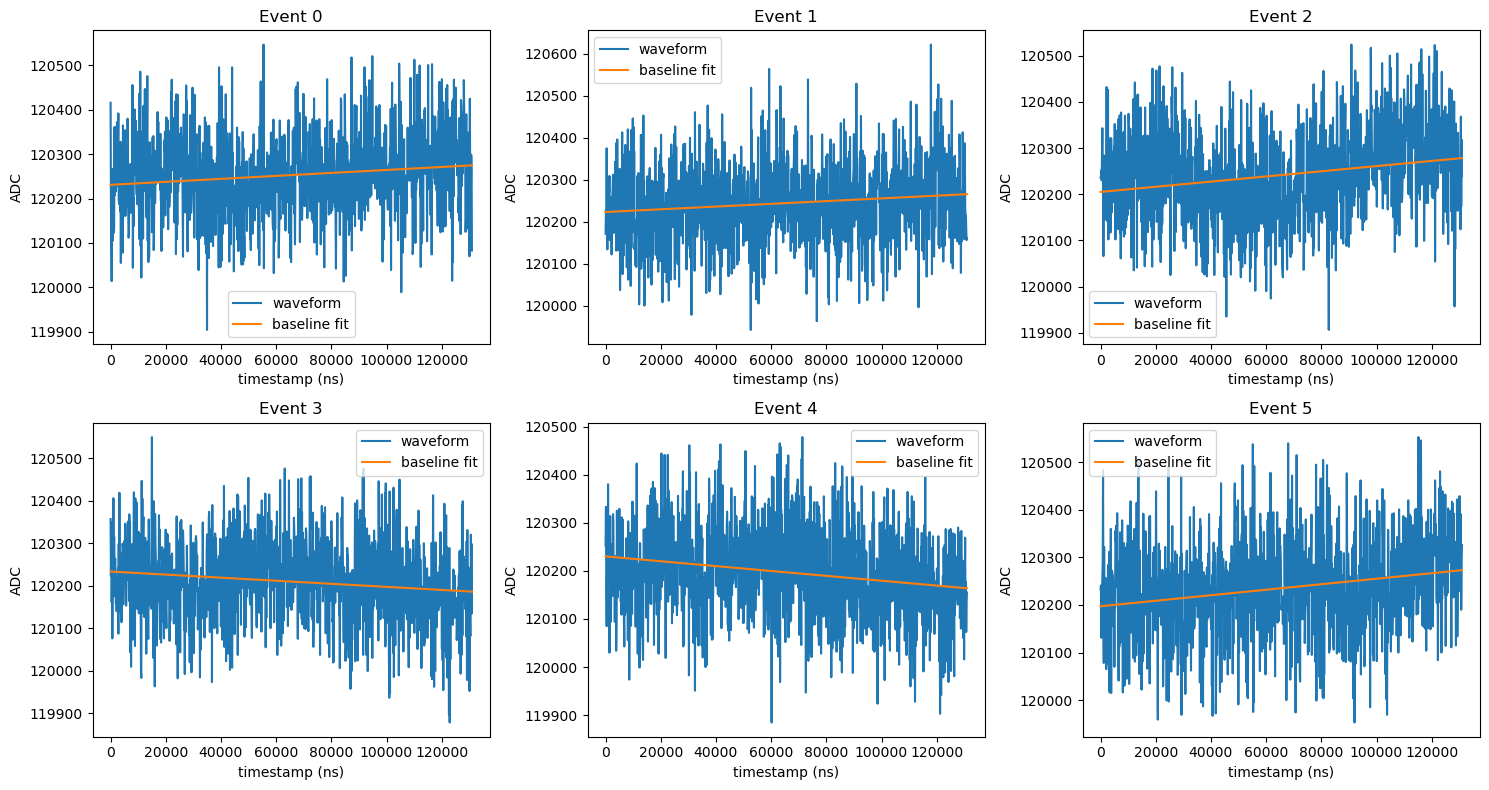

In [37]:
n_events = 6

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i in range(n_events):

    wf = wfs_ADC[i]
    t0 = data_init["waveform_presummed"][i]["t0"]
    dt = data_init["waveform_presummed"][i]["dt"]

    # asse tempo (o samples se preferisci)
    timestamp = t0 + np.arange(len(wf)) * dt

    # baseline fit
    x_fit = np.arange(len(wf))
    baseline = calcs["bl_int"][i] + calcs["bl_slope"][i] * x_fit

    ax = axes[i]
    ax.plot(timestamp, wf, label="waveform")
    ax.plot(timestamp, baseline, label="baseline fit")

    ax.set_title(f"Event {i}")
    ax.set_xlabel("timestamp (ns)")
    ax.set_ylabel("ADC")
    ax.legend()

plt.tight_layout()
plt.show()

[8.52390570e+01 1.26743794e-03 5.93609969e-02 7.61936206e-02]
[7.07342304e-01 5.48182891e-04 6.06935769e-04 2.65717895e-01]


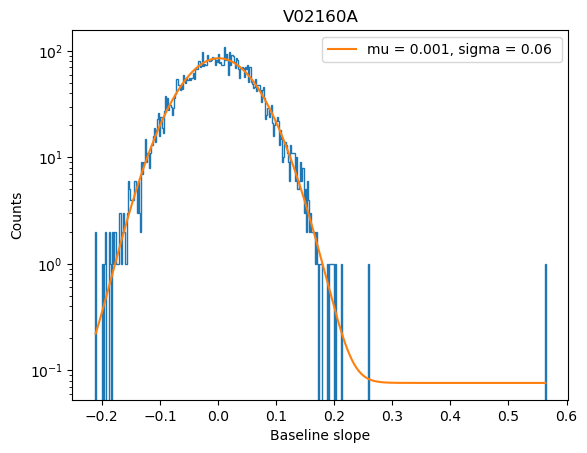

In [85]:
# Distirbution of the bl_sòlope parmaeter
# Here i'lll collect the mean and the  sigma in order to build the classifier
from scipy.optimize import curve_fit

counts, bc, _ = plt.hist(calcs["bl_slope"], bins = 400, histtype = 'step')
be = (bc[1:] + bc[:-1])/2

p0 = [max(counts), 0.1, 0.1, 0]
popt, pcov = curve_fit(
        gaussian,
        be,
        counts,
        p0=p0,
        maxfev=5000
    )
mu = popt[1]
sigma = popt[2]

print(popt)
print(np.sqrt(np.diag(pcov)))

plt.plot(be, gaussian(be, *popt), label = f"mu = {popt[1]:.3f}, sigma = {popt[2]:.2f} ")

plt.legend(loc = "upper right")
plt.ylabel(f"Counts")
plt.xlabel("Baseline slope")
plt.title(f"{detector}")
plt.yscale('log')

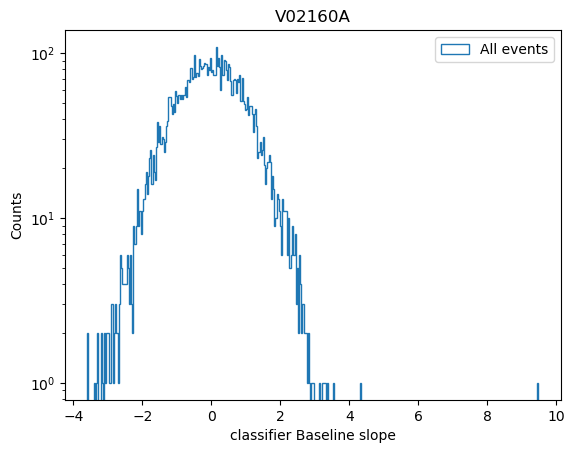

In [94]:
classifier_bl_slope = (calcs["bl_slope"] - mu) / sigma

counts, bc, _ = plt.hist(classifier_bl_slope, bins = 400, histtype = 'step', label=  "All events")

'''
be = (bc[1:] + bc[:-1])/2
p0 = [max(counts), 0.1, 0.1, 0]
popt, pcov = curve_fit(
        gaussian,
        be,
        counts,
        p0=p0,
        maxfev=5000
    )
mu = popt[1]
sigma = popt[2]

print(popt)
print(np.sqrt(np.diag(pcov)))
plt.plot(be, gaussian(be, *popt), label = f"mu = {popt[1]:.3f}, sigma = {popt[2]:.2f} ")'''

plt.legend(loc = "upper right")
plt.ylabel(f"Counts")
plt.xlabel("classifier Baseline slope")
plt.title(f"{detector}")
plt.yscale('log')